<a href="https://www.kaggle.com/code/yeasminbenin/day-6-linearregression-another?scriptVersionId=343493481" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
os.listdir("/kaggle/input")

['datasets']

In [3]:
os.listdir("/kaggle/input/datasets")

['yeasminbenin']

In [4]:
os.listdir("/kaggle/input/datasets/yeasminbenin")

['regression-stock-dataa']

In [5]:
os.listdir("/kaggle/input/datasets/yeasminbenin/regression-stock-dataa")

['regression_stock_dataa.csv']

In [6]:
df = pd.read_csv("/kaggle/input/datasets/yeasminbenin/regression-stock-dataa/regression_stock_dataa.csv")

In [7]:
df

,Date,Starting (USD),Ending (USD)
0,01.12.23,17650,17970
1,01.11.23,17100,16920
2,01.10.23,16850,17260
3,01.09.23,17300,16950
4,01.08.23,16500,16720
5,01.07.23,16200,16680
6,01.06.23,15800,15650
7,01.05.23,16050,16325
8,01.04.23,15400,15100
9,01.03.23,14950,15140


In [8]:
df.head()

,Date,Starting (USD),Ending (USD)
0,01.12.23,17650,17970
1,01.11.23,17100,16920
2,01.10.23,16850,17260
3,01.09.23,17300,16950
4,01.08.23,16500,16720


In [9]:
df.shape

(19, 3)

In [10]:
df.isnull()

,Date,Starting (USD),Ending (USD)
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,False,False
9,False,False,False


In [11]:
df.isnull().sum()

Date              0
Starting (USD)    0
Ending (USD)      0
dtype: int64

In [12]:
df = df.drop('Date', axis=1)

In [13]:
df

,Starting (USD),Ending (USD)
0,17650,17970
1,17100,16920
2,16850,17260
3,17300,16950
4,16500,16720
5,16200,16680
6,15800,15650
7,16050,16325
8,15400,15100
9,14950,15140


# Scatter plot

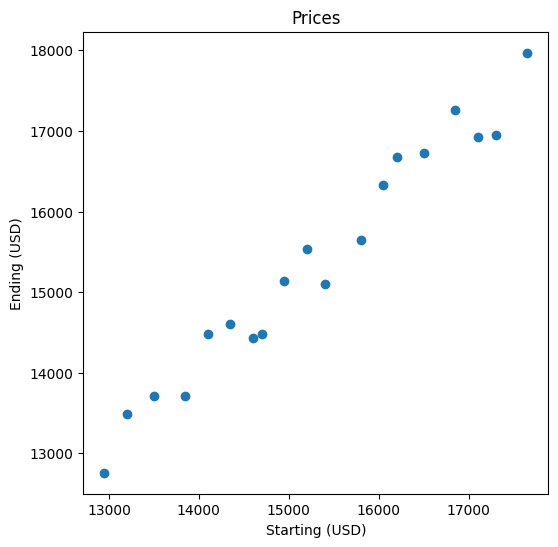

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(df['Starting (USD)'], df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('Prices')
plt.show()

# Separate x,y

In [15]:
x = df.drop(columns = 'Ending (USD)')

In [16]:
x

,Starting (USD)
0,17650
1,17100
2,16850
3,17300
4,16500
5,16200
6,15800
7,16050
8,15400
9,14950


In [17]:
y = df['Ending (USD)']

In [18]:
y

0     17970
1     16920
2     17260
3     16950
4     16720
5     16680
6     15650
7     16325
8     15100
9     15140
10    15540
11    14480
12    14610
13    14430
14    14480
15    13710
16    13710
17    13490
18    12760
Name: Ending (USD), dtype: int64

# Import LR

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
reg = LinearRegression()

In [21]:
reg

LinearRegression()

In [22]:
x.mean()

Starting (USD)    15276.315789
dtype: float64

In [23]:
y.mean()

np.float64(15364.473684210527)

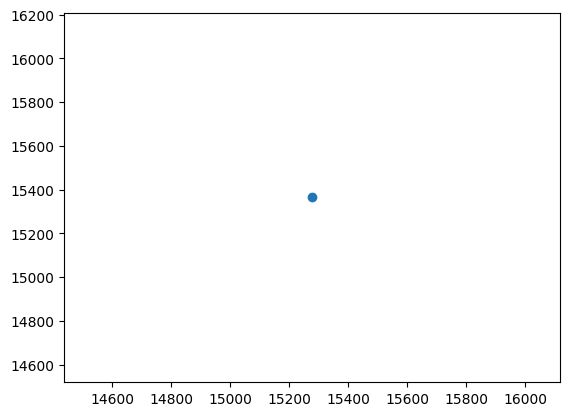

In [24]:
plt.scatter(x.mean(), y.mean())

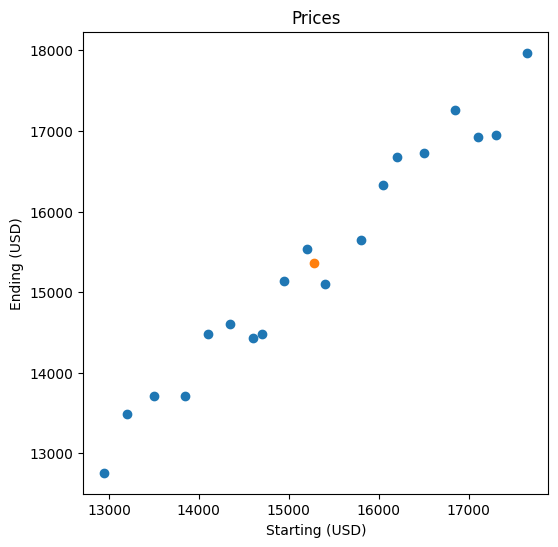

In [25]:
plt.figure(figsize=(6, 6))
plt.scatter(df['Starting (USD)'], df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('Prices')
plt.scatter(x.mean(), y.mean())


# fit

In [26]:
reg.fit(x, y)

LinearRegression()

In [27]:
reg.coef_

array([1.00842921])

In [28]:
reg.intercept_

np.float64(-40.60932386274544)

In [29]:
reg.predict([[18200]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([18312.80223235])

In [30]:
reg.predict(x)

array([17758.16616884, 17203.53010533, 16951.42280373, 17405.21594661,
       16598.4725815 , 16295.94381958, 15892.57213703, 16144.67943862,
       15489.20045447, 15035.4073116 , 15287.5146132 , 14783.30001   ,
       14430.34978777, 14682.45708937, 14178.24248617, 13926.13518458,
       13573.18496234, 13270.65620043, 13018.54889883])

In [31]:
df['predicted_y']=reg.predict(x)

In [32]:
df

,Starting (USD),Ending (USD),predicted_y
0,17650,17970,17758.166169
1,17100,16920,17203.530105
2,16850,17260,16951.422804
3,17300,16950,17405.215947
4,16500,16720,16598.472581
5,16200,16680,16295.943820
6,15800,15650,15892.572137
7,16050,16325,16144.679439
8,15400,15100,15489.200454
9,14950,15140,15035.407312


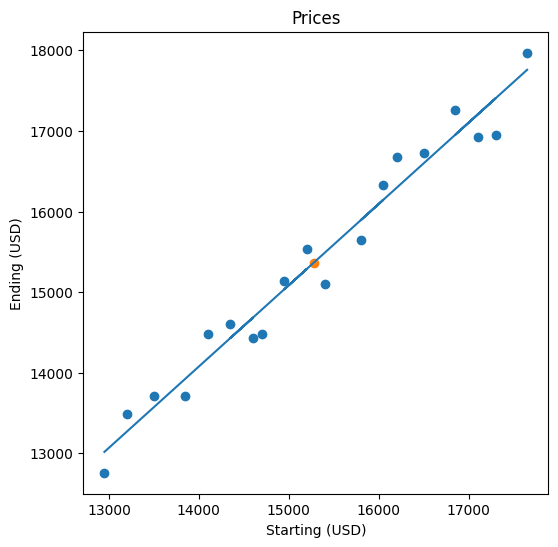

In [33]:
plt.figure(figsize=(6, 6))
plt.scatter(df['Starting (USD)'], df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('Prices')
plt.scatter(x.mean(), y.mean())
plt.plot(x, df['predicted_y'])